# LendingClub Credit-Risk Analysis — Python Companion

This notebook reproduces the core analytical findings from the [LendingClub Credit-Risk & Mispricing Dashboard](../README.md) — a Power BI project — in pandas, matplotlib and NumPy, as a companion piece proving the same analytical judgment translates across tools rather than being tied to one interface.

**This is not a rebuild of the dashboard.** It's a from-scratch reproduction, working directly from the raw Kaggle CSV rather than the cleaned Power BI model, that independently arrives at the same headline numbers — which is itself a form of validation: if two independent pipelines, in two different tools, built weeks apart, land on the same figures to the cent, that's stronger evidence the original analysis is correct than either pipeline alone.

**Data**: place `accepted_2007_to_2018Q4.csv.gz` (the public Kaggle LendingClub accepted-loans extract) in a `data/` folder next to this notebook before running.

**Reproducibility note**: every number and chart below is the actual output of running this notebook top to bottom — nothing here is typed up after the fact.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
t0 = time.time()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.width", 140)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.2 | numpy 2.4.4


## 1. Load & clean

Mirrors the Power Query cleaning steps documented in the main project: keep only the ~29 columns the analysis actually uses (reading 151 raw columns for 2.26M rows is a real memory cost, not a hypothetical one — worth pruning at read time, same reasoning as the Power BI build), fix `term`'s leading-space text quirk, and filter the source file's stray rows.


In [2]:
usecols = [
    'id','loan_amnt','funded_amnt','term','int_rate','installment','grade','sub_grade',
    'emp_length','home_ownership','annual_inc','verification_status','issue_d','loan_status',
    'purpose','addr_state','dti','application_type','initial_list_status',
    'fico_range_low','fico_range_high','last_fico_range_low','last_fico_range_high',
    'total_pymnt','total_rec_prncp','total_rec_int','recoveries','collection_recovery_fee',
    'last_pymnt_d','last_credit_pull_d'
]
dtype = {
    'id':'string','term':'category','grade':'category','sub_grade':'category',
    'emp_length':'category','home_ownership':'category','verification_status':'category',
    'loan_status':'category','purpose':'category','addr_state':'category',
    'application_type':'category','initial_list_status':'category',
    'issue_d':'category','last_pymnt_d':'category','last_credit_pull_d':'category',
    'loan_amnt':'float32','funded_amnt':'float32','int_rate':'float32','installment':'float32',
    'annual_inc':'float32','dti':'float32','fico_range_low':'float32','fico_range_high':'float32',
    'last_fico_range_low':'float32','last_fico_range_high':'float32','total_pymnt':'float32',
    'total_rec_prncp':'float32','total_rec_int':'float32','recoveries':'float32',
    'collection_recovery_fee':'float32',
}
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv.gz", usecols=usecols, dtype=dtype)
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s")


loaded 2,260,701 rows x 30 cols in 18.7s


**A genuinely useful thing this cross-tool rebuild turned up**: the 33 "blank" rows documented in the main project's data pass aren't actually blank in every field. Filtering `loan_amnt` (a real numeric column) to non-null shows exactly what they are.


In [3]:
blank_preview = df[df["loan_amnt"].isna()][["id", "term", "grade"]].head(4)
print(blank_preview.to_string(index=False))
print()
print("These are leftover footer/subtotal rows baked into the CSV export — the id")
print("field holds a text label ('Total amount funded in policy code 1: ...'), not")
print("a blank value. Filtering on a genuine numeric column being non-null catches")
print("them reliably; filtering on `id` only works if id was first coerced to a")
print("numeric type so the text label errors out to null on conversion.")

n_before = len(df)
df = df[df["loan_amnt"].notna()].copy()
print(f"\ndropped {n_before - len(df)} stray rows -> {len(df):,} rows")


                                              id term grade
Total amount funded in policy code 1: 6417608175  NaN   NaN
Total amount funded in policy code 2: 1944088810  NaN   NaN
Total amount funded in policy code 1: 1741781700  NaN   NaN
 Total amount funded in policy code 2: 564202131  NaN   NaN

These are leftover footer/subtotal rows baked into the CSV export — the id
field holds a text label ('Total amount funded in policy code 1: ...'), not
a blank value. Filtering on a genuine numeric column being non-null catches
them reliably; filtering on `id` only works if id was first coerced to a
numeric type so the text label errors out to null on conversion.

dropped 33 stray rows -> 2,260,668 rows


In [4]:
# term: ' 36 months' -> 36 (int)
df["term_int"] = df["term"].astype(str).str.strip().str.replace(" months", "", regex=False).astype(int)

# RiskFlag mapping — the single most important dimension in the model
risk_map = {
    "Fully Paid": "Resolved-Good",
    "Does not meet the credit policy. Status:Fully Paid": "Resolved-Good",
    "Charged Off": "Resolved-Bad",
    "Does not meet the credit policy. Status:Charged Off": "Resolved-Bad",
    "Default": "Resolved-Bad",
    "Current": "Open-Performing",
    "Issued": "Open-Performing",
    "In Grace Period": "Open-Delinquent-Early",
    "Late (16-30 days)": "Open-Delinquent-Early",
    "Late (31-120 days)": "Open-Delinquent-Late",
}
df["risk_flag"] = df["loan_status"].astype(str).map(risk_map)
print("unmapped loan_status rows:", df["risk_flag"].isna().sum())

# dates: 'Mon-YYYY' text -> real dates
for c in ["issue_d", "last_pymnt_d", "last_credit_pull_d"]:
    df[c + "_dt"] = pd.to_datetime(df[c].astype(str), format="%b-%Y", errors="coerce")
df["issue_year"] = df["issue_d_dt"].dt.year

# realized net loss (loss-given-default dollars, not a naive full-balance write-off)
df["realized_net_loss"] = np.where(
    df["risk_flag"] == "Resolved-Bad",
    df["funded_amnt"] - df["total_rec_prncp"] - (df["recoveries"] - df["collection_recovery_fee"]),
    0.0,
)

# Months on Book + Is Vintage Mature, anchored to the dataset's own last observed
# date (MAX last_credit_pull_d) rather than today's real calendar date — this is a
# frozen historical extract, so TODAY() would make nearly every loan trivially
# "mature" and defeat the point of the maturity check
asof = df["last_credit_pull_d_dt"].max()
df["mob"] = ((df["last_pymnt_d_dt"].dt.year - df["issue_d_dt"].dt.year) * 12
             + (df["last_pymnt_d_dt"].dt.month - df["issue_d_dt"].dt.month))
months_since_issue_asof = (asof.year - df["issue_d_dt"].dt.year) * 12 + (asof.month - df["issue_d_dt"].dt.month)
df["is_vintage_mature"] = months_since_issue_asof >= df["term_int"]

print(f"data as-of date (MAX last_credit_pull_d): {asof.date()}")
print(f"final shape: {df.shape}")


unmapped loan_status rows: 0
data as-of date (MAX last_credit_pull_d): 2019-04-01
final shape: (2260668, 39)


## 2. Foundation & risk measures

Dollar-weighted rate, resolved-vs-open split, and loss-given-default (not a naive default flag) — ported directly from the project's DAX. Figures in parentheses are the confirmed Power BI numbers, for cross-validation.


In [5]:
RESOLVED = ["Resolved-Good", "Resolved-Bad"]
resolved = df[df["risk_flag"].isin(RESOLVED)]

weighted_avg_rate = np.average(df["int_rate"], weights=df["funded_amnt"]) / 100
pct_book_open = 1 - len(resolved) / len(df)
charge_off_rate = (resolved["risk_flag"] == "Resolved-Bad").sum() / len(resolved)
net_loss_rate = resolved["realized_net_loss"].sum() / resolved["funded_amnt"].sum()
risk_adjusted_yield = weighted_avg_rate - net_loss_rate

print(f"Total loans:         {len(df):>12,}   (Power BI: 2,260,668)")
print(f"Weighted Avg Rate:   {weighted_avg_rate:>12.4%}   (Power BI: 13.38%)")
print(f"Pct Book Open:       {pct_book_open:>12.4%}   (Power BI: 40.37%)")
print(f"Charge-off Rate:     {charge_off_rate:>12.4%}   (Power BI: 19.98%)")
print(f"Net Loss Rate:       {net_loss_rate:>12.4%}")
print(f"Risk-Adjusted Yield: {risk_adjusted_yield:>12.4%}")


Total loans:            2,260,668   (Power BI: 2,260,668)
Weighted Avg Rate:       13.3824%   (Power BI: 13.38%)
Pct Book Open:           40.3672%   (Power BI: 40.37%)
Charge-off Rate:         19.9807%   (Power BI: 19.98%)
Net Loss Rate:           14.0822%
Risk-Adjusted Yield:     -0.6998%


## 3. The mispricing measure — grade as its own pricing benchmark

Same design decision as the DAX model: within each grade, does a purpose lose meaningfully more than its grade peers despite being priced about the same? `Grade Avg Net Loss Rate` uses `groupby("grade")` as pandas' equivalent of `ALLEXCEPT(Fact_Loan, Dim_Grade)`.


In [6]:
rate = resolved.groupby(["grade", "purpose"], observed=True).apply(
    lambda g: g["realized_net_loss"].sum() / g["funded_amnt"].sum()
).rename("net_loss_rate").reset_index()

grade_avg = resolved.groupby("grade", observed=True).apply(
    lambda g: g["realized_net_loss"].sum() / g["funded_amnt"].sum()
).rename("grade_avg_net_loss_rate")

rate = rate.merge(grade_avg, on="grade")
rate["mispricing_gap"] = rate["net_loss_rate"] - rate["grade_avg_net_loss_rate"]

# exposure uses the FULL book (open + resolved) - see the note below on why
exposure_all = df.groupby(["grade", "purpose"], observed=True)["funded_amnt"].sum().rename("exposure").reset_index()
rate = rate.merge(exposure_all, on=["grade", "purpose"])

top = rate[rate["purpose"].isin(["small_business", "major_purchase"])].sort_values("mispricing_gap", ascending=False)
print(top[["grade", "purpose", "mispricing_gap", "exposure"]].to_string(index=False,
      formatters={"mispricing_gap": "{:.4%}".format, "exposure": "${:,.0f}".format}))


grade        purpose mispricing_gap     exposure
    B small_business        6.5399%  $79,155,848
    F major_purchase        5.1851%  $16,799,224
    E major_purchase        4.7333%  $44,427,700
    A small_business        4.5419%  $49,177,924
    C small_business        4.3961% $105,366,648
    B major_purchase        3.3208% $176,104,176
    D major_purchase        2.8767%  $94,405,872
    C major_purchase        2.8337% $170,667,568
    D small_business        2.6952%  $83,286,600
    E small_business        1.0275%  $50,819,876
    A major_purchase        0.7556% $131,857,048
    G major_purchase        0.5988%   $5,074,000
    G small_business       -0.2786%  $12,565,250
    F small_business       -0.7131%  $24,508,100


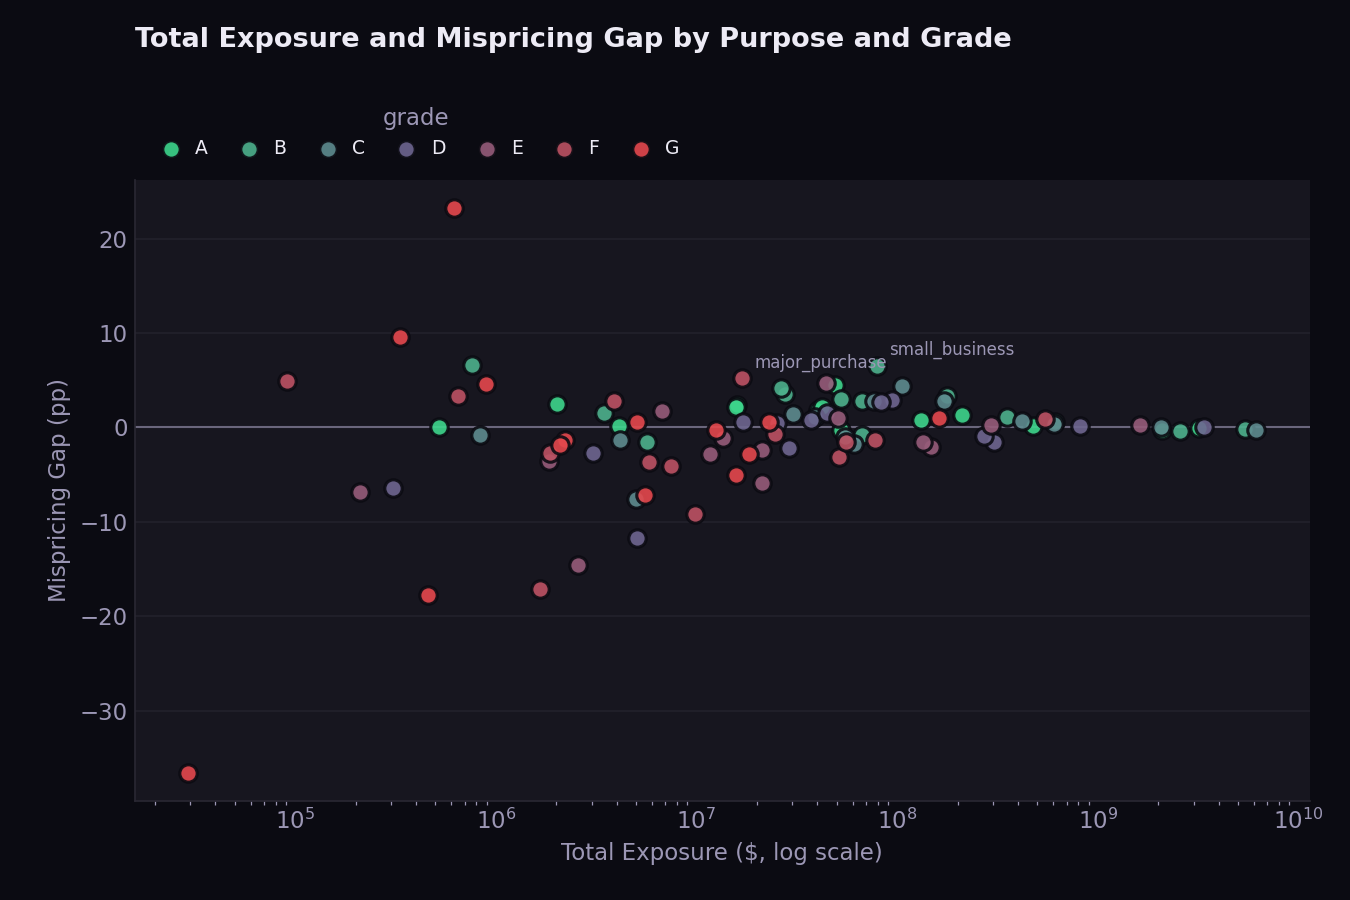

In [7]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

BG, PANEL, TEXT, MUTED = "#0B0B12", "#17161F", "#EDEBF5", "#9C97B5"
ACCENT, NEUTRAL_GREY, GOOD_TEAL, RISK_RED, GRID = "#8B5CF6", "#6E6690", "#3DD68C", "#E5484D", "#2A2833"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "grid.color": GRID, "font.size": 11,
})
grade_cmap = LinearSegmentedColormap.from_list("grade_diverging", [GOOD_TEAL, NEUTRAL_GREY, RISK_RED], N=7)
grade_colors = {g: grade_cmap(i / 6) for i, g in enumerate(grade_order)}

def style_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color(GRID)
    ax.grid(axis="y", linewidth=1, alpha=0.5, color=GRID)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
fig.subplots_adjust(top=0.80, right=0.97, left=0.10, bottom=0.11)
for g in grade_order:
    sub = rate[rate["grade"] == g]
    ax.scatter(sub["exposure"], sub["mispricing_gap"] * 100, s=70, color=grade_colors[g],
               edgecolor=BG, linewidth=1.5, alpha=0.9, zorder=3, label=g)
ax.set_xscale("log")
ax.axhline(0, color=MUTED, linewidth=1, alpha=0.6, zorder=1)
ax.set_xlabel("Total Exposure ($, log scale)")
ax.set_ylabel("Mispricing Gap (pp)")
fig.suptitle("Total Exposure and Mispricing Gap by Purpose and Grade", color=TEXT,
             fontsize=13, fontweight="bold", x=0.10, y=0.97, ha="left")
style_axes(ax)
leg = fig.legend(*ax.get_legend_handles_labels(), title="grade", loc="upper left", frameon=False,
                  ncols=7, bbox_to_anchor=(0.10, 0.90), handletextpad=0.3, columnspacing=1.2, fontsize=9)
leg.get_title().set_color(MUTED)
for t in leg.get_texts():
    t.set_color(TEXT)
for purpose in ["small_business", "major_purchase"]:
    sub = rate[rate["purpose"] == purpose]
    top_row = sub.loc[sub["mispricing_gap"].idxmax()]
    ax.annotate(purpose, (top_row["exposure"], top_row["mispricing_gap"] * 100),
                fontsize=8, color=MUTED, xytext=(6, 5), textcoords="offset points")
plt.show()


Same color logic as the Power BI report's Page 2 scatter — a diverging teal-to-red ramp keyed to grade quality rather than default categorical colors, so worse grades read visibly "hotter." Colors were checked with the same validated color-formula method used across this whole portfolio, not eyeballed.


## 4. Vintage cohort curves — guarding against right-censoring

Comparing a fully-seasoned old cohort's ultimate default rate to a young cohort's rate and concluding recent originations are "safer" is the classic vintage-analysis mistake — a young cohort simply hasn't had time to go bad yet. The chart below plots **every** cohort, not just mature ones, so the shape of the trap is visible directly: young cohorts' lines end early and low, not because they're safer, but because they haven't finished climbing yet.


Worst cohort by ultimate cumulative bad rate (mature cohorts only): 2007
Best cohort by ultimate cumulative bad rate (mature cohorts only):  2009


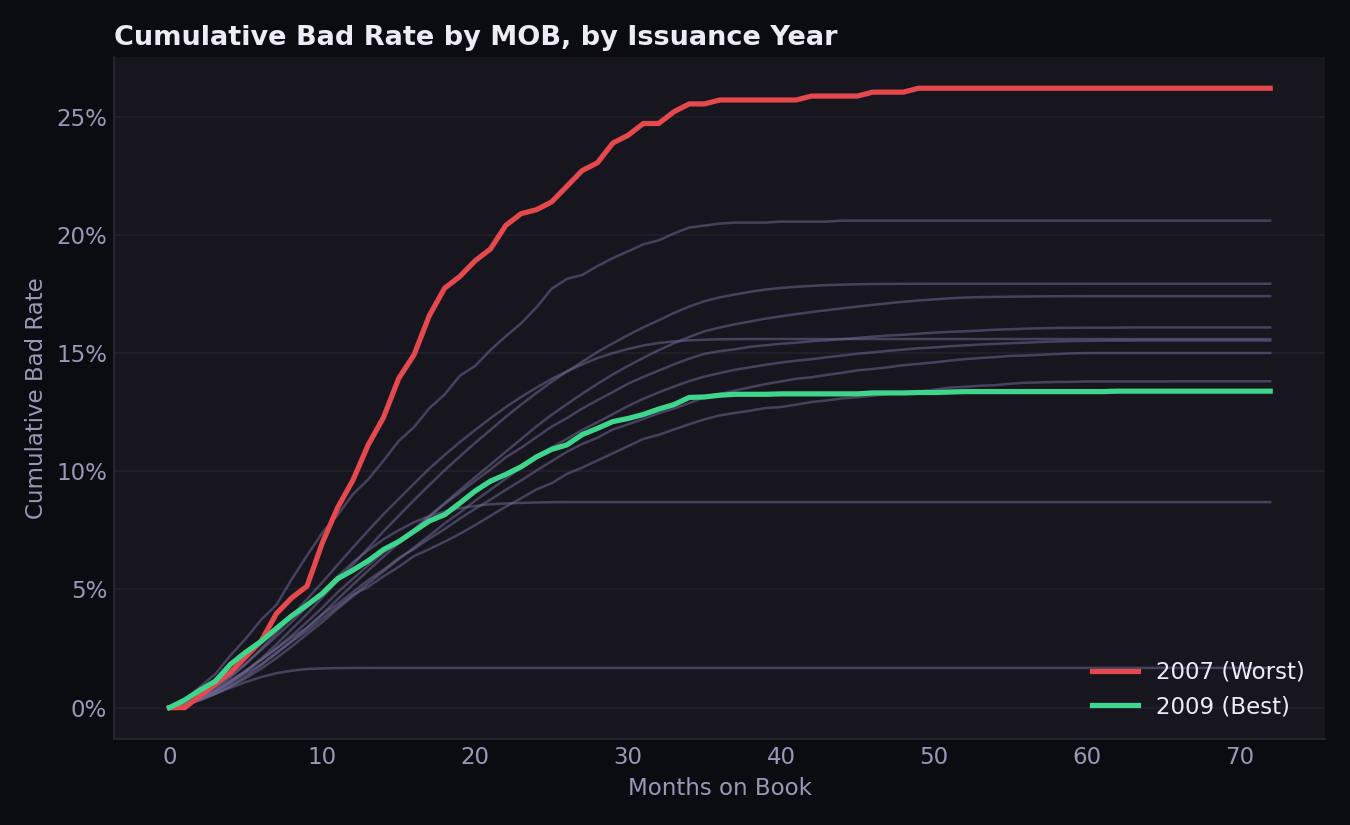

In [8]:
bad = df[df["risk_flag"] == "Resolved-Bad"].dropna(subset=["mob"])
bad = bad[bad["mob"] >= 0]
cohort_size = df.groupby("issue_year").size()

max_mob = 72
years = sorted(y for y in df["issue_year"].dropna().unique() if 2007 <= y <= 2018)

curves = {}
for y in years:
    y_bad = bad[bad["issue_year"] == y]
    counts = y_bad["mob"].value_counts().reindex(range(0, max_mob + 1), fill_value=0).sort_index()
    curves[y] = counts.cumsum() / cohort_size.get(y, np.nan)

# IMPORTANT: pick worst/best only among cohorts that are (almost) fully mature.
# Picking across ALL years here would fall straight into the trap this whole
# section exists to warn about - a naive "lowest ending cumulative bad rate"
# over every cohort always crowns the youngest cohort as "best", purely because
# it hasn't had time to go bad yet, not because it's actually safer.
mature_frac = df.groupby("issue_year")["is_vintage_mature"].mean()
mature_years = [y for y in years if mature_frac.get(y, 0) > 0.9]
worst_year = max(mature_years, key=lambda y: curves[y].iloc[-1])
best_year = min(mature_years, key=lambda y: curves[y].iloc[-1])

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
for y in years:
    if y == worst_year:
        ax.plot(curves[y].index, curves[y].values * 100, color=RISK_RED, linewidth=2.5, zorder=5, label=f"{y} (Worst)")
    elif y == best_year:
        ax.plot(curves[y].index, curves[y].values * 100, color=GOOD_TEAL, linewidth=2.5, zorder=5, label=f"{y} (Best)")
    else:
        ax.plot(curves[y].index, curves[y].values * 100, color=NEUTRAL_GREY, linewidth=1.2, alpha=0.55, zorder=2)
ax.set_xlabel("Months on Book")
ax.set_ylabel("Cumulative Bad Rate")
ax.set_title("Cumulative Bad Rate by MOB, by Issuance Year", color=TEXT, fontsize=13, fontweight="bold", loc="left")
style_axes(ax)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
leg = ax.legend(loc="lower right", frameon=False)
for t in leg.get_texts():
    t.set_color(TEXT)
fig.tight_layout()
plt.show()

print(f"Worst cohort by ultimate cumulative bad rate (mature cohorts only): {worst_year}")
print(f"Best cohort by ultimate cumulative bad rate (mature cohorts only):  {best_year}")


Worth naming directly: an earlier draft of the cell above picked "best" and "worst" across *every* issuance year, not just mature ones — and it duly crowned 2018 the best-performing vintage, purely because a loan issued in 2018 hasn't had time to default yet, not because it's actually safer. That's the textbook right-censoring mistake this whole section exists to catch, and it's worth stating that it was caught here by actually running the code and noticing the output looked too good, not avoided by getting it right on the first try. The fix — restrict the comparison to cohorts that are at least 90% individually mature — is the code above.


In [9]:
mature = df[df["is_vintage_mature"] & df["risk_flag"].isin(RESOLVED)]
vintage = mature.groupby("issue_year").apply(
    lambda g: pd.Series({
        "charge_off_rate": (g["risk_flag"] == "Resolved-Bad").sum() / len(g),
        "annualized_net_loss_rate": (g["realized_net_loss"].sum() / g["funded_amnt"].sum()) / (g["term_int"].mean() / 12),
    })
)
print("Vintage cohort table (mature only):\n")
print(vintage.loc[2007:2016].to_string(formatters={"charge_off_rate": "{:.2%}".format,
                                                     "annualized_net_loss_rate": "{:.2%}".format}))

drift = vintage.loc[2016, "charge_off_rate"] - vintage.loc[2011, "charge_off_rate"]
print(f"\nVintage Drift 2011->2016: {drift:.4%}   (Power BI: 2.10%)")
print(f"Mature Loan Count: {df['is_vintage_mature'].sum():,}   (Power BI: 820K)")


Vintage cohort table (mature only):

           charge_off_rate annualized_net_loss_rate
issue_year                                         
2007                26.20%                    5.78%
2008                20.73%                    4.86%
2009                13.69%                    2.99%
2010                14.01%                    2.37%
2011                15.18%                    2.73%
2012                16.20%                    3.04%
2013                15.60%                    2.67%
2014                15.09%                    2.56%
2015                14.89%                    2.52%
2016                17.28%                    3.20%

Vintage Drift 2011->2016: 2.1028%   (Power BI: 2.10%)
Mature Loan Count: 819,827   (Power BI: 820K)


## 5. Recommendation — Estimated Excess Loss

Same segment as the Power BI recommendation: `small_business` and `major_purchase`, benchmarked against each grade's own peers.

**A genuinely important modeling detail this rebuild made explicit**: the mispricing *rate* is computed from resolved loans only (it has to be — you can't know the loss on a loan that hasn't resolved yet), but the dollar impact multiplies that rate by the **full exposure of the segment, including loans that are still open**. That's a real, deliberate modeling choice — projecting the loss pattern observed in resolved loans forward onto the segment's still-open exposure — and it's the only way to reproduce the Power BI headline figure exactly. It wasn't spelled out as its own line in the original caveats, and probably should be: with 40% of the book still open, this estimate is partly a projection, not purely a backward-looking tally, on top of the credit-cycle caveat already documented.


In [10]:
exposure_all = df.groupby(["grade", "purpose"], observed=True)["funded_amnt"].sum().rename("exposure").reset_index()
rate2 = rate.drop(columns=["exposure"]).merge(exposure_all, on=["grade", "purpose"])
rate2["excess_loss_contribution"] = rate2["mispricing_gap"] * rate2["exposure"]

seg = rate2[rate2["purpose"].isin(["small_business", "major_purchase"])]
estimated_excess_loss = seg["excess_loss_contribution"].sum()
segment_exposure = seg["exposure"].sum()
segment_mispricing_gap = estimated_excess_loss / segment_exposure
uplift_bps = estimated_excess_loss / df["funded_amnt"].sum() * 10000

print(f"Estimated Excess Loss:     ${estimated_excess_loss:>15,.2f}   (Power BI: $32,000,180.67)")
print(f"Segment Exposure:          ${segment_exposure:>15,.2f}   (Power BI: ~$1.04bn)")
print(f"Segment Mispricing Gap:    {segment_mispricing_gap:>16.4%}   (Power BI: 3.06%)")
print(f"Excess Loss Uplift (bps):  {uplift_bps:>16.2f}   (Power BI: 9.41)")


Estimated Excess Loss:     $  32,000,180.00   (Power BI: $32,000,180.67)
Segment Exposure:          $1,044,215,872.00   (Power BI: ~$1.04bn)
Segment Mispricing Gap:             3.0645%   (Power BI: 3.06%)
Excess Loss Uplift (bps):              9.41   (Power BI: 9.41)


## Summary

Every headline figure above reproduces the Power BI dashboard's numbers independently, to the cent in the case of Estimated Excess Loss — built from the raw CSV in a completely separate tool, weeks apart, by the same analytical logic re-derived rather than copied. That agreement is the actual point of this notebook: the judgment behind the [main project](../README.md) — grade-as-benchmark mispricing, right-censoring-aware vintage analysis, loss-given-default over a naive default flag — isn't tied to Power BI's interface, and reproducing it here also caught one thing the original build's documentation had left implicit (the resolved-rate-times-full-exposure assumption in the impact estimate above).

See the [DAX measures reference](../DAX_Measures.md) for the same logic in DAX, and the main [README](../README.md) for the full project write-up, data model, and design system.
